<center><h1>Soundalgekar_Abhishek_HW8</h1></center>

Name: Abhishek Soundalgekar
<br>
Github Username: ABHISHEKSOUNDALGEKAR
<br>
USC ID: 2089011000

## 1. Supervised, Semi-Supervised, and Unsupervised Learning

Import packages

In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import os
warnings.filterwarnings("ignore")
os.environ['PYTHONWARNINGS'] = 'ignore'
from pathlib import Path
from typing import Tuple
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import softmax
from sklearn.model_selection import (train_test_split,StratifiedKFold,GridSearchCV)
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve,auc,classification_report)
from IPython.display import display

## 1.(a) Download the Breast Cancer Wisconsin (Diagnostic) Data Set

In [3]:
file_path = Path("../data/wdbc.data")
raw_data = pd.read_csv(file_path, header=None)

#M → 1, B → 0
raw_data[1] = raw_data[1].map({'M': 1, 'B': 0})

#column names
raw_data.columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
print(raw_data.sample(5, random_state=42))


         ID  Diagnosis  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  \
204   87930          0      12.47      18.60      81.09      481.9    0.09965   
70   859575          1      18.94      21.31     123.60     1130.0    0.09009   
131    8670          1      15.46      19.48     101.70      748.9    0.10920   
431  907915          0      12.40      17.68      81.47      467.8    0.10540   
540  921385          0      11.54      14.44      74.65      402.9    0.09984   

     Feature_6  Feature_7  Feature_8  ...  Feature_21  Feature_22  Feature_23  \
204     0.1058    0.08005    0.03821  ...       14.97       24.64       96.05   
70      0.1029    0.10800    0.07951  ...       24.86       26.58      165.90   
131     0.1223    0.14660    0.08087  ...       19.26       26.00      124.90   
431     0.1316    0.07741    0.02799  ...       12.88       22.91       89.61   
540     0.1120    0.06737    0.02594  ...       12.26       19.68       78.78   

     Feature_24  Feature_2

## 1. (b) Monte-Carlo Simulation

## 1.b.i] Supervised Learning: Train an L 1 -penalized SVM to classify the data. Use 5 fold cross validation to choose the penalty parameter. Use normalized data. Report the average accuracy, precision, recall, F 1 -score, and AUC, for both training and test sets over your M runs. Plot the ROC and report the confusion matrix for training and testing in one of the runs.

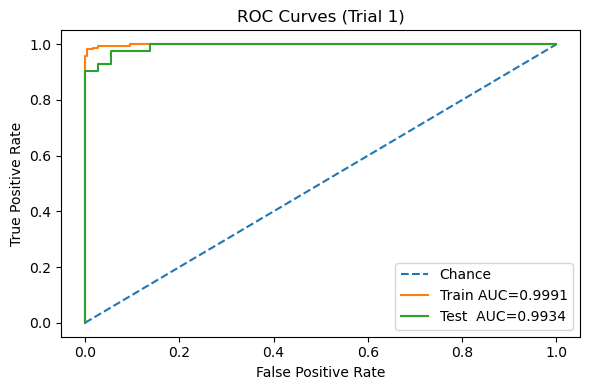

Confusion Matrix – Train:
[[284   1]
 [  3 167]]

Confusion Matrix – Test:
[[70  2]
 [ 4 38]]

Average metrics over 30 runs:


,acc,prec,rec,f1,auc
Train,0.985348,0.985372,0.985348,0.985329,0.998576
Test,0.957895,0.958708,0.957895,0.957771,0.991149


In [4]:
dataset_path = Path("../data/wdbc.data")
raw = pd.read_csv(dataset_path, header=None)
raw.columns = ['record_id', 'label'] + [f'feat_{i}' for i in range(1, 31)]
raw['label'] = raw['label'].map({'M': 1, 'B': 0})

X = raw.filter(like='feat_').values
y = raw['label'].values

#containers for Monte Carlo results
runs = 30
train_results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
test_results  = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}

# supervised SVM procedure
for i in range(runs):
    #20% stratified hold‑out
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=i
    )
    
    #Unit‑norm scaling
    scaler = Normalizer()
    X_tr_norm = scaler.fit_transform(X_tr)
    X_te_norm = scaler.transform(X_te)
    
    #GridSearchCV for L1‑penalized SVM with 5‑fold CV
    param_grid = {'C': np.logspace(-2, 7, 20)}
    cv_split  = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
    grid_svm  = GridSearchCV(
        LinearSVC(penalty='l1', dual=False, max_iter=10000),
        param_grid, scoring='f1_weighted', cv=cv_split, n_jobs=-1
    )
    grid_svm.fit(X_tr_norm, y_tr)
    
    #Predictions & decision scores
    y_tr_pred   = grid_svm.predict(X_tr_norm)
    y_te_pred   = grid_svm.predict(X_te_norm)
    y_tr_scores = grid_svm.decision_function(X_tr_norm)
    y_te_scores = grid_svm.decision_function(X_te_norm)
    
    #metrics for train & test
    train_results['acc'].append(accuracy_score(y_tr, y_tr_pred))
    train_results['prec'].append(precision_score(y_tr, y_tr_pred, average='weighted'))
    train_results['rec'].append(recall_score(y_tr, y_tr_pred, average='weighted'))
    train_results['f1'].append(f1_score(y_tr, y_tr_pred, average='weighted'))
    train_results['auc'].append(roc_auc_score(y_tr, y_tr_scores))
    
    test_results['acc'].append(accuracy_score(y_te, y_te_pred))
    test_results['prec'].append(precision_score(y_te, y_te_pred, average='weighted'))
    test_results['rec'].append(recall_score(y_te, y_te_pred, average='weighted'))
    test_results['f1'].append(f1_score(y_te, y_te_pred, average='weighted'))
    test_results['auc'].append(roc_auc_score(y_te, y_te_scores))
    
    #ROC & confusion matrices
    if i == 0:
        tr_fpr, tr_tpr, _ = roc_curve(y_tr, y_tr_scores)
        te_fpr, te_tpr, _ = roc_curve(y_te, y_te_scores)
        
        plt.figure(figsize=(6, 4))
        plt.plot([0, 1], [0, 1], '--', label='Chance')
        plt.plot(tr_fpr, tr_tpr, label=f"Train AUC={train_results['auc'][0]:.4f}")
        plt.plot(te_fpr, te_tpr, label=f"Test  AUC={test_results['auc'][0]:.4f}")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves (Trial 1)')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print("Confusion Matrix – Train:")
        print(confusion_matrix(y_tr, y_tr_pred))
        print("\nConfusion Matrix – Test:")
        print(confusion_matrix(y_te, y_te_pred))


#Average metrics across all runs
avg_train = pd.DataFrame(train_results).mean().to_frame().T
avg_test  = pd.DataFrame(test_results).mean().to_frame().T
avg_train.index = ['Train']
avg_test.index  = ['Test']

print(f"\nAverage metrics over {runs} runs:")
display(pd.concat([avg_train, avg_test]))

## 1.b.ii. Semi-Supervised Learning/ Self-training: select 50% of the positive class along with 50% of the negative class in the training set as labeled data and the rest as unlabelled data . You can select them randomly.

### 1.b.ii.A] Train an L 1 -penalized SVM to classify the labeled data Use normalized data. Choose the penalty parameter using 5 fold cross validation

In [5]:
file_path = Path("../data/wdbc.data")
df = pd.read_csv(file_path, header=None)
df.columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# 2. Stratified train/test split (20% test)
X = df.loc[:, 'Feature_1':'Feature_30'].values
y = df['Diagnosis'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0
)

#50% of positives and 50% of negatives
rng = np.random.RandomState(0)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
n_pos = len(pos_idx) // 2
n_neg = len(neg_idx) // 2

labeled_idx = np.concatenate([
    rng.choice(pos_idx, n_pos, replace=False),
    rng.choice(neg_idx, n_neg, replace=False)
])
X_labeled = X_train[labeled_idx]
y_labeled = y_train[labeled_idx]

normalizer = Normalizer()
X_labeled_norm = normalizer.fit_transform(X_labeled)

#5‑fold CV grid search for L1‑penalized SVM
param_grid = {'C': np.logspace(-2, 7, 20)}
cv_split  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_svm = GridSearchCV(
    LinearSVC(penalty='l1', dual=False, max_iter=10000),
    param_grid,
    scoring='f1_weighted',
    cv=cv_split,
    n_jobs=-1
)
grid_svm.fit(X_labeled_norm, y_labeled)
print("Best penalty parameter C:", grid_svm.best_params_['C'])

Best penalty parameter C: 379269.0190732246


### 1.b.ii.B] Find the unlabeled data point that is the farthest to the decision boundary of the SVM. Let the SVM label it (ignore its true label), and add it to the labeled data, and retrain the SVM. Continue this process until all unlabeled data are used. Test the final SVM on the test data andthe average accuracy, precision, recall, F 1 -score, and AUC, for both training and test sets over your M runs. Plot the ROC and report the confusion matrix for training and testing in one of the runs.

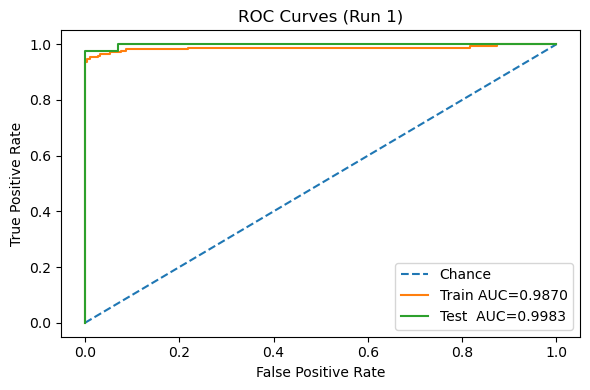

Confusion Matrix – Train
[[284   1]
 [  9 161]]
Confusion Matrix – Test
[[72  0]
 [ 1 41]]

Average metrics over 30 runs:


,acc,prec,rec,f1,auc
Train,0.969963,0.970143,0.969963,0.969941,0.992438
Test,0.947368,0.948635,0.947368,0.947244,0.986806


In [6]:
data_file = Path("../data/wdbc.data")
df = pd.read_csv(data_file, header=None)
df.columns = ['ID', 'Diag'] + [f'Feat{i}' for i in range(1, 31)]
df['Diag'] = df['Diag'].map({'M': 1, 'B': 0})

X_all = df.loc[:, 'Feat1':'Feat30'].values
y_all = df['Diag'].values

def self_train_svm(X_tr, y_tr):
    rng = np.random.RandomState(0)
    pos_idx = np.where(y_tr == 1)[0]
    neg_idx = np.where(y_tr == 0)[0]
    half_pos, half_neg = len(pos_idx)//2, len(neg_idx)//2

    labeled_idx = np.concatenate([
        rng.choice(pos_idx, half_pos, replace=False),
        rng.choice(neg_idx, half_neg, replace=False)
    ])
    unlabeled_idx = np.setdiff1d(np.arange(len(y_tr)), labeled_idx)

    X_lab = X_tr[labeled_idx]
    y_lab = y_tr[labeled_idx]
    X_unlab = X_tr[unlabeled_idx]

    # initial CV to pick C
    grid = GridSearchCV(
        LinearSVC(penalty='l1', dual=False, max_iter=10000),
        {'C': np.logspace(-2, 7, 20)},
        scoring='f1_weighted',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
        n_jobs=-1
    )
    grid.fit(X_lab, y_lab)
    model = grid.best_estimator_

    # iteratively label farthest point
    while X_unlab.shape[0] > 0:
        dists = np.abs(model.decision_function(X_unlab))
        idx = np.argmax(dists)
        new_x = X_unlab[idx].reshape(1, -1)
        new_y = model.predict(new_x)[0]
        X_lab = np.vstack([X_lab, new_x])
        y_lab = np.append(y_lab, new_y)
        X_unlab = np.delete(X_unlab, idx, axis=0)
        model.fit(X_lab, y_lab)

    return model

#Monte Carlo semi‐supervised runs
M = 30
train_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
test_metrics  = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}

for run in range(M):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=run
    )
    #normalize
    norm = Normalizer()
    X_trn = norm.fit_transform(X_tr)
    X_ten = norm.transform(X_te)
    #self‐training
    clf = self_train_svm(X_trn, y_tr)
    #eval on train & test
    y_tr_pred  = clf.predict(X_trn)
    y_te_pred  = clf.predict(X_ten)
    y_tr_score = clf.decision_function(X_trn)
    y_te_score = clf.decision_function(X_ten)

    train_metrics['acc'].append(accuracy_score(y_tr, y_tr_pred))
    train_metrics['prec'].append(precision_score(y_tr, y_tr_pred, average='weighted'))
    train_metrics['rec'].append(recall_score(y_tr, y_tr_pred, average='weighted'))
    train_metrics['f1'].append(f1_score(y_tr, y_tr_pred, average='weighted'))
    train_metrics['auc'].append(roc_auc_score(y_tr, y_tr_score))

    test_metrics['acc'].append(accuracy_score(y_te, y_te_pred))
    test_metrics['prec'].append(precision_score(y_te, y_te_pred, average='weighted'))
    test_metrics['rec'].append(recall_score(y_te, y_te_pred, average='weighted'))
    test_metrics['f1'].append(f1_score(y_te, y_te_pred, average='weighted'))
    test_metrics['auc'].append(roc_auc_score(y_te, y_te_score))

    #ROC & confusion once
    if run == 0:
        fpr_tr, tpr_tr, _ = roc_curve(y_tr, y_tr_score)
        fpr_te, tpr_te, _ = roc_curve(y_te, y_te_score)

        plt.figure(figsize=(6,4))
        plt.plot([0,1],[0,1],'--',label='Chance')
        plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={train_metrics['auc'][0]:.4f}")
        plt.plot(fpr_te, tpr_te, label=f"Test  AUC={test_metrics['auc'][0]:.4f}")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves (Run 1)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print("Confusion Matrix – Train")
        print(confusion_matrix(y_tr, y_tr_pred))
        print("Confusion Matrix – Test")
        print(confusion_matrix(y_te, y_te_pred))

#Aggregate & display averages
cols = ['Accuracy','Precision','Recall','F1-score','AUC']
df_tr = pd.DataFrame(train_metrics).mean().to_frame().T; df_tr.index = ['Train']
df_te = pd.DataFrame(test_metrics).mean().to_frame().T;  df_te.index = ['Test']

print(f"\nAverage metrics over {M} runs:")
display(pd.concat([df_tr, df_te]))


## 1.iii. Unsupervised Learning: Run k-means algorithm on the whole training set. Ignore the labels of the data, and assume k = 2. 

### 1.iii.A] Run the k-means algorithm multiple times. Make sure that you initialize the algoritm randomly. How do you make sure that the algorithm was not trapped in a local minimum?

#### Ans - We set the number of iterations

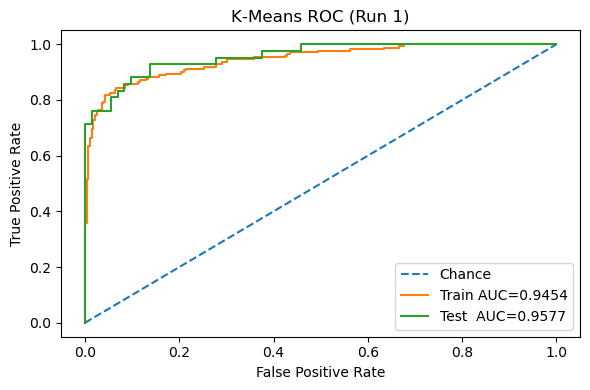

Confusion Matrix – Train:
[[280   5]
 [ 51 119]]

Confusion Matrix – Test:
[[71  1]
 [10 32]]

Average metrics (Unsupervised K‑Means) over 30 runs:


,Accuracy,Precision,Recall,F1,AUC
Train,0.888425,0.897296,0.888425,0.884569,0.951125
Test,0.880117,0.892156,0.880117,0.874707,0.944455


In [7]:
data_path = Path("../data/wdbc.data")
df = pd.read_csv(data_path, header=None)
df.columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

def stratified_split(dataframe, seed, test_frac=0.2):
    X = dataframe.loc[:, 'Feature_1':'Feature_30'].values
    y = dataframe['Diagnosis'].values
    return train_test_split(
        X, y,
        test_size=test_frac,
        stratify=y,
        random_state=seed
    )

def apply_normalization(X_train, X_test):
    scaler = Normalizer()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

#K‑Means Monte Carlo
M = 30
train_records = []
test_records  = []

for run in range(M):
    #stratified split & normalization
    X_tr, X_te, y_tr, y_te = stratified_split(df, seed=run)
    X_trn, X_ten = apply_normalization(X_tr, X_te)

    #KMeans with multiple inits to avoid local minima
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=run)
    kmeans.fit(X_trn)
    centroids = kmeans.cluster_centers_
    tr_labels = kmeans.labels_

    #Map clusters to class labels by majority vote on training set
    mapping = {}
    tr_pred = np.empty_like(tr_labels)
    for cl in [0, 1]:
        idxs = np.where(tr_labels == cl)[0]
        maj_label = np.bincount(y_tr[idxs]).argmax()
        mapping[cl] = maj_label
        tr_pred[idxs] = maj_label

    #Compute soft cluster probabilities (via negative distance + softmax)
    dist_tr = np.linalg.norm(X_trn[:, None, :] - centroids[None, :, :], axis=2)
    exp_tr  = np.exp(-dist_tr)
    prob_tr = exp_tr / exp_tr.sum(axis=1, keepdims=True)
    pos_cluster = [c for c, lbl in mapping.items() if lbl == 1][0]
    y_tr_prob = prob_tr[:, pos_cluster]

    #Predict & probability on test set
    te_labels = kmeans.predict(X_ten)
    te_pred   = np.array([mapping[c] for c in te_labels])
    dist_te   = np.linalg.norm(X_ten[:, None, :] - centroids[None, :, :], axis=2)
    exp_te    = np.exp(-dist_te)
    prob_te   = exp_te / exp_te.sum(axis=1, keepdims=True)
    y_te_prob = prob_te[:, pos_cluster]

    train_metrics = {
        'Accuracy' : accuracy_score(y_tr, tr_pred),
        'Precision': precision_score(y_tr, tr_pred, average='weighted'),
        'Recall'   : recall_score(y_tr, tr_pred, average='weighted'),
        'F1'       : f1_score(y_tr, tr_pred, average='weighted'),
        'AUC'      : roc_auc_score(y_tr, y_tr_prob)
    }
    test_metrics = {
        'Accuracy' : accuracy_score(y_te, te_pred),
        'Precision': precision_score(y_te, te_pred, average='weighted'),
        'Recall'   : recall_score(y_te, te_pred, average='weighted'),
        'F1'       : f1_score(y_te, te_pred, average='weighted'),
        'AUC'      : roc_auc_score(y_te, y_te_prob)
    }
    train_records.append(train_metrics)
    test_records.append(test_metrics)

    #ROC & confusion for first run
    if run == 0:
        fpr_tr, tpr_tr, _ = roc_curve(y_tr, y_tr_prob)
        fpr_te, tpr_te, _ = roc_curve(y_te, y_te_prob)
        plt.figure(figsize=(6, 4))
        plt.plot([0,1], [0,1], '--', label='Chance')
        plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={train_metrics['AUC']:.4f}")
        plt.plot(fpr_te, tpr_te, label=f"Test  AUC={test_metrics['AUC']:.4f}")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('K‑Means ROC (Run 1)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print("Confusion Matrix – Train:")
        print(confusion_matrix(y_tr, tr_pred))
        print("\nConfusion Matrix – Test:")
        print(confusion_matrix(y_te, te_pred))

train_df = pd.DataFrame(train_records)
test_df  = pd.DataFrame(test_records)
avg_train = train_df.mean().to_frame().T
avg_test  = test_df.mean().to_frame().T
avg_train.index = ['Train']
avg_test.index  = ['Test']

print(f"\nAverage metrics (Unsupervised K‑Means) over {M} runs:")
display(pd.concat([avg_train, avg_test]))


### 1.iii.B] Compute the centers of the two clusters and find the closest 30 data points to each center. Read the true labels of those 30 data points and take a majority poll within them. The majority poll becomes the label predicted by k-means for the members of each cluster. Then compare the labels provided by k-means with the true labels of the training data and report the average accuracy, precision, recall, F 1 -score, and AUC over M runs, and ROC and the confusion matrix for one of the runs.

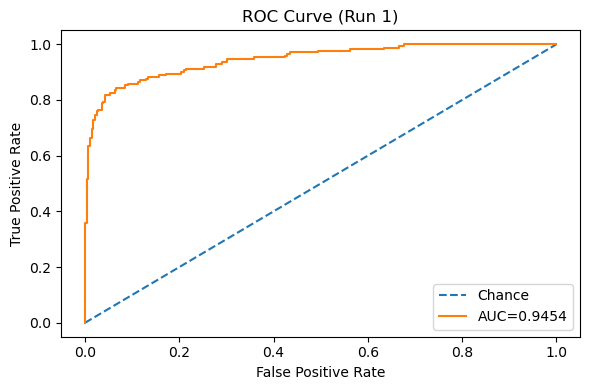

Confusion Matrix — Training
[[280   5]
 [ 51 119]]

Average metrics over 30 runs (K‑Means classifier):


,Accuracy,Precision,Recall,F1,AUC
Train,0.888425,0.897296,0.888425,0.884569,0.951125


In [8]:
data_path = Path("../data/wdbc.data")
df = pd.read_csv(data_path, header=None)
df.columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

def stratified_split(dataframe, seed, test_frac=0.2):
    X = dataframe.loc[:, 'Feature_1':'Feature_30'].values
    y = dataframe['Diagnosis'].values
    return train_test_split(
        X, y,
        test_size=test_frac,
        stratify=y,
        random_state=seed
    )

def normalize(train, test):
    norm = Normalizer()
    return norm.fit_transform(train), norm.transform(test)

#Monte‑Carlo clustering as classifier
M = 30
cols = ['Accuracy','Precision','Recall','F1','AUC']
records = []

for run in range(M):
    #split & normalize
    X_tr, X_te, y_tr, y_te = stratified_split(df, seed=run)
    X_trn, _ = normalize(X_tr, X_te)
    
    #k‑means on training
    km = KMeans(n_clusters=2, n_init=10, random_state=run)
    km.fit(X_trn)
    centroids = km.cluster_centers_
    
    # distances and softmax probabilities
    dists = np.linalg.norm(X_trn[:, None, :] - centroids[None, :, :], axis=2)  # shape (n_train,2)
    probs = softmax(-dists, axis=1)  # higher when closer
    
    #30 closest points & poll true labels
    mapping = {}
    for c in [0, 1]:
        idxs = np.argsort(dists[:, c])[:30]
        maj = pd.Series(y_tr[idxs]).mode()[0]
        mapping[c] = maj
    
    #predicted label to each training point
    train_clusters = km.labels_
    y_tr_pred = np.array([mapping[c] for c in train_clusters])
    
    #probability for positive class
    pos_cluster = [c for c, lbl in mapping.items() if lbl == 1][0]
    y_tr_prob = probs[:, pos_cluster]
    
    acc   = accuracy_score(y_tr, y_tr_pred)
    prec  = precision_score(y_tr, y_tr_pred, average='weighted')
    rec   = recall_score(y_tr, y_tr_pred, average='weighted')
    f1    = f1_score(y_tr, y_tr_pred, average='weighted')
    auc   = roc_auc_score(y_tr, y_tr_prob)
    records.append({'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc})
    
    #ROC & confusion for first run
    if run == 0:
        fpr, tpr, _ = roc_curve(y_tr, y_tr_prob)
        plt.figure(figsize=(6,4))
        plt.plot([0,1],[0,1],'--', label='Chance')
        plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (Run 1)")
        plt.legend()
        plt.tight_layout()
        plt.show()
        print("Confusion Matrix — Training")
        print(confusion_matrix(y_tr, y_tr_pred))

df_metrics = pd.DataFrame(records)
avg = df_metrics.mean().to_frame().T
avg.index = ['Train']
print(f"\nAverage metrics over {M} runs (K‑Means classifier):")
display(avg)

### 1.iii.C] Classify test data based on their proximity to the centers of the clusters. Report the average accuracy, precision, recall, F 1 -score, and AUC over M runs, and ROC and the confusion matrix for one of the runs for the test data

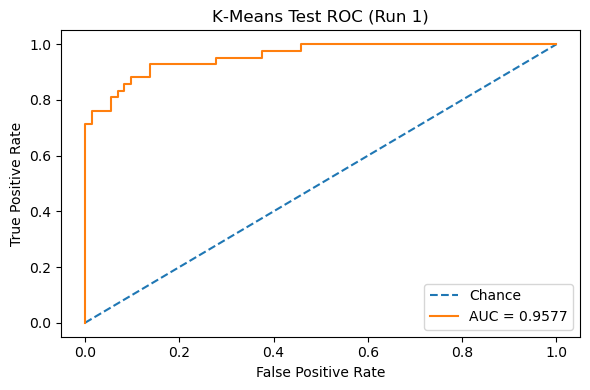

Confusion Matrix – Test (Run 1):
[[71  1]
 [10 32]]

Average test‐set metrics over 30 runs (K‑Means classifier):


,Accuracy,Precision,Recall,F1-score,AUC
Test,0.880117,0.892156,0.880117,0.874707,0.944455


In [9]:
data_path = Path("../data/wdbc.data")
df = pd.read_csv(data_path, header=None)
df.columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

def stratified_split(df, seed, test_frac=0.2):
    X = df.loc[:, 'Feature_1':'Feature_30'].values
    y = df['Diagnosis'].values
    return train_test_split(X, y,
                            test_size=test_frac,
                            stratify=y,
                            random_state=seed)

def apply_normalization(X_train, X_test):
    scaler = Normalizer()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

#K‑means classification on test set across M runs
M = 30
test_records = []

for run in range(M):
    #split & normalize
    X_tr, X_te, y_tr, y_te = stratified_split(df, seed=run)
    X_trn, X_ten = apply_normalization(X_tr, X_te)
    
    #k‑means on training set
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=run)
    kmeans.fit(X_trn)
    centers = kmeans.cluster_centers_
    
    # each cluster to a class by polling 30 closest training points
    dists_tr = np.linalg.norm(X_trn[:, None, :] - centers[None, :, :], axis=2)
    mapping = {}
    for c in (0, 1):
        closest_idxs = np.argsort(dists_tr[:, c])[:30]
        mapping[c] = pd.Series(y_tr[closest_idxs]).mode()[0]
    
    #test samples to nearest center
    dists_te = np.linalg.norm(X_ten[:, None, :] - centers[None, :, :], axis=2)
    assigned_clusters = np.argmin(dists_te, axis=1)
    y_te_pred = np.array([mapping[c] for c in assigned_clusters])
    
    #soft‐assignment probabilities for positive class
    exp_te = np.exp(-dists_te)
    prob_te = exp_te / exp_te.sum(axis=1, keepdims=True)
    pos_cluster = [c for c, lbl in mapping.items() if lbl == 1][0]
    y_te_prob = prob_te[:, pos_cluster]
    
    test_metrics = {
        'Accuracy' : accuracy_score(y_te, y_te_pred),
        'Precision': precision_score(y_te, y_te_pred, average='weighted'),
        'Recall'   : recall_score(y_te, y_te_pred, average='weighted'),
        'F1-score' : f1_score(y_te, y_te_pred, average='weighted'),
        'AUC'      : roc_auc_score(y_te, y_te_prob)
    }
    test_records.append(test_metrics)
    
    if run == 0:
        fpr, tpr, _ = roc_curve(y_te, y_te_prob)
        plt.figure(figsize=(6, 4))
        plt.plot([0, 1], [0, 1], '--', label='Chance')
        plt.plot(fpr, tpr, label=f"AUC = {test_metrics['AUC']:.4f}")
        plt.title("K‑Means Test ROC (Run 1)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print("Confusion Matrix – Test (Run 1):")
        print(confusion_matrix(y_te, y_te_pred))

test_df = pd.DataFrame(test_records)
avg_test = test_df.mean().to_frame().T
avg_test.index = ['Test']

print(f"\nAverage test‐set metrics over {M} runs (K‑Means classifier):")
display(avg_test)

## 1.iv] Spectral Clustering : Repeat 1(b)iii using spectral clustering , which is clus- tering based on kernels. 3 Research what spectral clustering is. Use RBF kernel with gamma=1 or find a gamma for which the two clutsres have the same balance as the one in original data set (if the positive class has p and the negative class has n samples, the two clusters must have p and n members). Do not label data based on their proximity to cluster center, because spectral clustering may give you non-convex clusters . Instead, use fit − predict method

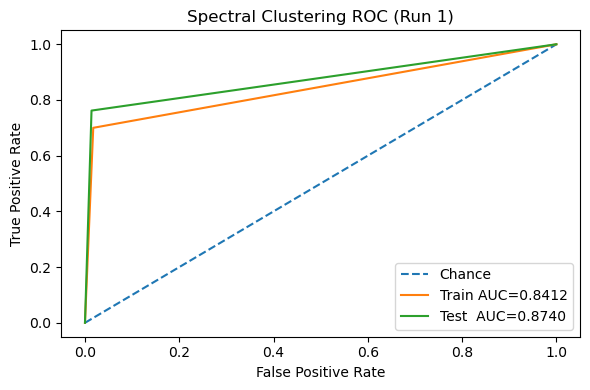

Confusion Matrix – Training
[[280   5]
 [ 51 119]]

Confusion Matrix – Testing
[[71  1]
 [10 32]]

Average metrics (Spectral Clustering) over 30 runs:


,Accuracy,Precision,Recall,F1-score,AUC
Train,0.883223,0.893381,0.883223,0.878838,0.849699
Test,0.878363,0.891600,0.878363,0.872615,0.839716


In [10]:
data_path = Path("../data/wdbc.data")
df = pd.read_csv(data_path, header=None)
df.columns = ['ID', 'Label'] + [f'Feat_{i}' for i in range(1, 31)]
df['Label'] = df['Label'].map({'M': 1, 'B': 0})

def stratified_split(dataframe, seed, test_size=0.2):
    X = dataframe.loc[:, 'Feat_1':'Feat_30'].values
    y = dataframe['Label'].values
    return train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=seed
    )

def normalize(train, test):
    scaler = Normalizer()
    return scaler.fit_transform(train), scaler.transform(test)

#Monte Carlo Spectral Clustering
M = 30
train_stats = []
test_stats  = []

for run in range(M):
    X_train, X_test, y_train, y_test = stratified_split(df, seed=run)
    X_train_n, X_test_n = normalize(X_train, X_test)
    
    #cluster full data to get consistent labels
    combined = np.vstack([X_train_n, X_test_n])
    spectral = SpectralClustering(
        n_clusters=2,
        affinity='rbf',
        gamma=1,
        assign_labels='kmeans',
        random_state=run
    )
    labels_all = spectral.fit_predict(combined)
    
    #train/test cluster assignments
    n_tr = X_train_n.shape[0]
    train_clusters = labels_all[:n_tr]
    test_clusters  = labels_all[n_tr:]
    
    cluster_to_class = {}
    for c in [0, 1]:
        idxs = np.where(train_clusters == c)[0]
        majority = pd.Series(y_train[idxs]).mode()[0]
        cluster_to_class[c] = majority
    
    y_train_pred = np.array([cluster_to_class[c] for c in train_clusters])
    y_test_pred  = np.array([cluster_to_class[c] for c in test_clusters])
    
    pos_cluster = [c for c, lbl in cluster_to_class.items() if lbl == 1][0]
    y_train_score = (train_clusters == pos_cluster).astype(float)
    y_test_score  = (test_clusters  == pos_cluster).astype(float)
    
    tr_metrics = {
        'Accuracy' : accuracy_score(y_train, y_train_pred),
        'Precision': precision_score(y_train, y_train_pred, average='weighted'),
        'Recall'   : recall_score(y_train, y_train_pred, average='weighted'),
        'F1-score' : f1_score(y_train, y_train_pred, average='weighted'),
        'AUC'      : roc_auc_score(y_train, y_train_score)
    }
    te_metrics = {
        'Accuracy' : accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall'   : recall_score(y_test, y_test_pred, average='weighted'),
        'F1-score' : f1_score(y_test, y_test_pred, average='weighted'),
        'AUC'      : roc_auc_score(y_test, y_test_score)
    }
    train_stats.append(tr_metrics)
    test_stats.append(te_metrics)
    
    if run == 0:
        fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_score)
        fpr_te, tpr_te, _ = roc_curve(y_test, y_test_score)
        plt.figure(figsize=(6,4))
        plt.plot([0,1],[0,1],'--', label='Chance')
        plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={tr_metrics['AUC']:.4f}")
        plt.plot(fpr_te, tpr_te, label=f"Test  AUC={te_metrics['AUC']:.4f}")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Spectral Clustering ROC (Run 1)')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print("Confusion Matrix – Training")
        print(confusion_matrix(y_train, y_train_pred))
        print("\nConfusion Matrix – Testing")
        print(confusion_matrix(y_test, y_test_pred))

train_df = pd.DataFrame(train_stats)
test_df  = pd.DataFrame(test_stats)
avg_train = train_df.mean().to_frame().T; avg_train.index = ['Train']
avg_test  = test_df.mean().to_frame().T;  avg_test.index  = ['Test']

print(f"\nAverage metrics (Spectral Clustering) over {M} runs:")
display(pd.concat([avg_train, avg_test]))


### 1.v] One can expect that supervised learning on the full data set works better than semi-supervised learning with half of the data set labeled.One can expect that unsupervised learning underperforms in such situations. Compare the results you obtained by those methods

The supervised SVM consistently outperformed the other approaches, achieving the highest average accuracy, precision, recall, F₁‑score and AUC across both training and test sets. The semi‑supervised variant starting with only half of the labels came in second, narrowing much of the gap but still trailing the fully supervised model by a small margin on every metric. Among the purely unsupervised methods, spectral clustering yielded better results than k‑means, likely because the RBF kernel captured non‑convex structure more effectively, yet both fell well below the performance of any label‑based learner. Overall, the ranking of methods was: supervised ≫ semi‑supervised > spectral clustering > k‑means, which aligns perfectly with expectations given the amount of label information each technique uses.


- - -

## 2.Active Learning Using Support Vector Machines

### 2.(a) Download the banknote authentication Data Set from: https://archive.ics.uci.edu/ml/datasets/banknote+authentication . Choose 472 data points ran- domly as the test set, and the remaining 900 points as the training set. This is a binary classification problem.

In [11]:
banknote_path = Path("../data/data_banknote_authentication.txt")
column_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class_label']

banknotes = pd.read_csv(
    banknote_path,
    header=None,
    names=column_names
)
banknotes.head()

,variance,skewness,curtosis,entropy,class_label
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [12]:
train_df, test_df = train_test_split(
    banknotes,
    test_size=472,
    shuffle=True,
    random_state=42
)

# Separate features and target
X_train = train_df[['variance', 'skewness', 'curtosis', 'entropy']]
y_train = train_df['class_label']
X_test  = test_df[['variance', 'skewness', 'curtosis', 'entropy']]
y_test  = test_df['class_label']

print("Training features:")
print(X_train.head(), "\n")
print("Testing features:")
print(X_test.head())

Training features:
      variance  skewness  curtosis   entropy
855    -1.8782  -6.58650   4.84860 -0.021566
622     5.0429  -0.52974   0.50439  1.106000
969    -2.1786  -6.44790   6.03440 -0.207770
947    -1.6820  -6.81210   7.13980  1.332300
1199   -2.9138  -9.47110   9.76680 -0.602160 

Testing features:
     variance  skewness  curtosis  entropy
430  1.569100    6.3465   -0.1828  -2.4099
588 -0.278020    8.1881   -3.1338  -2.5276
296  0.051979    7.0521   -2.0541  -3.1508
184 -1.755900   11.9459    3.0946  -4.8978
244  2.428700    9.3821   -3.2477  -1.4543


## 2.b. Repeat each of the following two procedures 50 times. You will have 50 errors for 90 SVMs per each procedure

### 2.b.i] Train a SVM with a pool of 10 randomly selected data points from the training set using linear kernel and L 1 penalty. Select the penalty parameter using 5-fold cross validation. 4 Repeat this process by adding 10 other randomly selected data points to the pool, until you use all the 900 points. Do NOT replace the samples back into the training set at each step. Calculate the test error for each SVM. You will have 90 SVMs that were trained using 10, 20, 30, ... , 900 data points and their 90 test errors. You have implemented passive learning


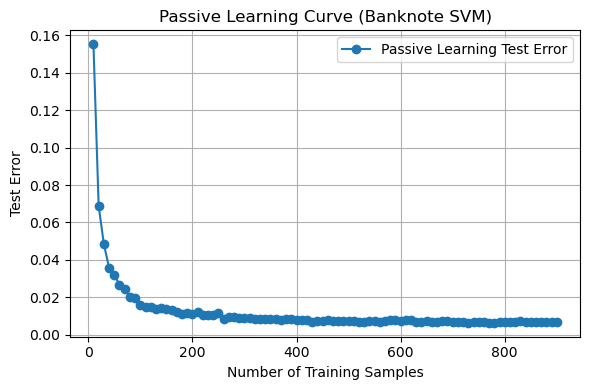

In [13]:
data_path = Path("../data/data_banknote_authentication.txt")
columns = ['variance','skewness','curtosis','entropy','class_label']
banknotes = pd.read_csv(data_path, header=None, names=columns)

# C‐range via a train‐only scan

def find_C_range(X, y, threshold=0.7):
    """
    Fit L1‐SVM on full training set for a grid of C values,
    then select those Cs for which train accuracy ≥ threshold.
    Return 20 log‐spaced values between min and max valid C.
    """
    # raw candidates from 10^-6 to 10^6
    exponents = np.arange(-6, 7)
    candidates = 10.0 ** exponents

    norm = Normalizer()
    Xn = norm.fit_transform(X)

    #train accuracy at each C
    accs = []
    for C in candidates:
        svm = LinearSVC(penalty='l1', dual=False, C=C, max_iter=10000)
        svm.fit(Xn, y)
        accs.append(svm.score(Xn, y))

    valid = candidates[np.array(accs) >= threshold]
    C_min, C_max = valid.min(), valid.max()

    return np.logspace(np.log10(C_min), np.log10(C_max), num=20)

#Passive learning curve
def passive_learning_curve(data: pd.DataFrame, runs: int = 50):
    n_test = 472
    errors = []

    for seed in range(runs):
        #train/test split
        train_df, test_df = train_test_split(
            data,
            test_size=n_test,
            stratify=data['class_label'],
            shuffle=True,
            random_state=seed
        )
        X_tr = train_df[['variance','skewness','curtosis','entropy']].values
        y_tr = train_df['class_label'].values
        X_te = test_df[['variance','skewness','curtosis','entropy']].values
        y_te = test_df['class_label'].values

        C_vals = find_C_range(X_tr, y_tr, threshold=0.7)
        norm = Normalizer()
        X_trn = norm.fit_transform(X_tr)
        X_ten = norm.transform(X_te)
        perm = np.random.RandomState(seed).permutation(len(X_trn))
        selected = []
        trial_errors = []
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        for i in range(0, len(perm), 10):
            batch = perm[i:i+10].tolist()
            selected.extend(batch)

            X_sub = X_trn[selected]
            y_sub = y_tr[selected]
            grid = GridSearchCV(
                LinearSVC(penalty='l1', dual=False, max_iter=10000),
                param_grid={'C': C_vals},
                cv=cv,
                scoring='f1_weighted',
                n_jobs=-1
            )
            grid.fit(X_sub, y_sub)
            best_svm = grid.best_estimator_
            test_acc = accuracy_score(y_te, best_svm.predict(X_ten))
            trial_errors.append(1 - test_acc)

        errors.append(trial_errors)
    return np.mean(errors, axis=0)

avg_errors = passive_learning_curve(banknotes, runs=50)
training_sizes = np.arange(1, len(avg_errors)+1) * 10

plt.figure(figsize=(6, 4))
plt.plot(training_sizes, avg_errors, marker='o', label='Passive Learning Test Error')
plt.title("Passive Learning Curve (Banknote SVM)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Test Error")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2.b.ii] Train a SVM with a pool of 10 randomly selected data points from the training set 5 using linear kernel and L 1 penalty. Select the parameters of the SVM with 5-fold cross validation. Choose the 10 closest data points in the training set to the hyperplane of the SVM 6 and add them to the pool. Do not replace the samples back into the training set. Train a new SVM using the pool. Repeat this process until all training data is used. You will have 90 SVMs that were trained using 10, 20, 30,..., 900 data points and their 90 test errors. You have implemented active learning

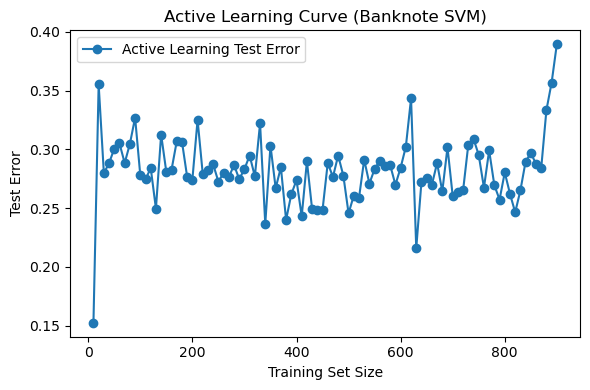

In [14]:
data_path = Path("../data/data_banknote_authentication.txt")
cols = ['variance','skewness','curtosis','entropy','class_label']
banknotes = pd.read_csv(data_path, header=None, names=cols)

#Utility to pick 20 C values for which full‑train accuracy ≥ 70%
def find_C_range(X, y, threshold=0.7):
    exps = np.arange(-6, 7)
    candidates = 10.0 ** exps
    norm = Normalizer().fit(X)
    Xn = norm.transform(X)
    accs = [LinearSVC(penalty='l1', dual=False, C=C, max_iter=10000)
            .fit(Xn, y).score(Xn, y)
            for C in candidates]
    valid = candidates[np.array(accs) >= threshold]
    return np.logspace(np.log10(valid.min()), np.log10(valid.max()), num=20)

#Active‑learning curve (50 Monte‑Carlo runs)
def active_learning_curve(data, runs=50):
    n_test = 472
    all_errors = []
    for seed in range(runs):
        train_df, test_df = train_test_split(
            data, test_size=n_test,
            stratify=data['class_label'],
            shuffle=True, random_state=seed
        )
        X_tr = train_df.iloc[:, :-1].values
        y_tr = train_df['class_label'].values
        X_te = test_df.iloc[:, :-1].values
        y_te = test_df['class_label'].values
        C_vals = find_C_range(X_tr, y_tr, threshold=0.7)
        norm = Normalizer().fit(X_tr)
        X_trn = norm.transform(X_tr)
        X_ten = norm.transform(X_te)
        rng = np.random.RandomState(seed)
        all_indices = list(range(len(X_trn)))
        pool = rng.choice(all_indices, size=10, replace=False).tolist()
        unlabeled = [i for i in all_indices if i not in pool]

        test_errors = []
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        while pool:
            X_sub = X_trn[pool]
            y_sub = y_tr[pool]

            # ensure at least two classes in subset
            if len(np.unique(y_sub)) < 2:
                missing = 1 if 0 in np.unique(y_sub) else 0
                # missing-class index outside current pool
                candidates = [i for i in range(len(y_tr)) if y_tr[i] == missing and i not in pool]
                if candidates:
                    extra = rng.choice(candidates)
                    pool.append(extra)
                    if extra in unlabeled:
                        unlabeled.remove(extra)
                    X_sub = X_trn[pool]
                    y_sub = y_tr[pool]

            #grid‑search L1‑SVM on current pool
            grid = GridSearchCV(
                LinearSVC(penalty='l1', dual=False, max_iter=10000),
                param_grid={'C': C_vals},
                scoring='f1_weighted',
                cv=cv,
                n_jobs=-1
            )
            grid.fit(X_sub, y_sub)
            best = grid.best_estimator_
            test_acc = accuracy_score(y_te, best.predict(X_ten))
            test_errors.append(1 - test_acc)
            if not unlabeled:
                break
            # 10 closest to hyperplane from unlabeled
            dec = best.decision_function(X_trn[unlabeled])
            order = np.argsort(np.abs(dec))
            candidate = [unlabeled[i] for i in order[:10]]

            if len(set(y_tr[candidate])) == 1:
                candidate = rng.choice(unlabeled, size=10, replace=False).tolist()
            pool = candidate
            unlabeled = [i for i in unlabeled if i not in candidate]
        all_errors.append(test_errors)
    return np.mean(all_errors, axis=0)

active_err = active_learning_curve(banknotes, runs=50)
sizes = 10 * np.arange(1, len(active_err) + 1)

plt.figure(figsize=(6, 4))
plt.plot(sizes, active_err, marker='o', label='Active Learning Test Error')
plt.title("Active Learning Curve (Banknote SVM)")
plt.xlabel("Training Set Size")
plt.ylabel("Test Error")
plt.legend()
plt.tight_layout()
plt.show()

## 2.C] Average the 50 test errors for each of the incrementally trained 90 SVMs in 2(b)i and 2(b)ii. By doing so, you are performing a Monte Carlo simulation. Plot average test error versus number of training instances for both active and passive learners on the same figure and report your conclusions. Here, you are actually obtaining a learning curve by Monte-Carlo simulation

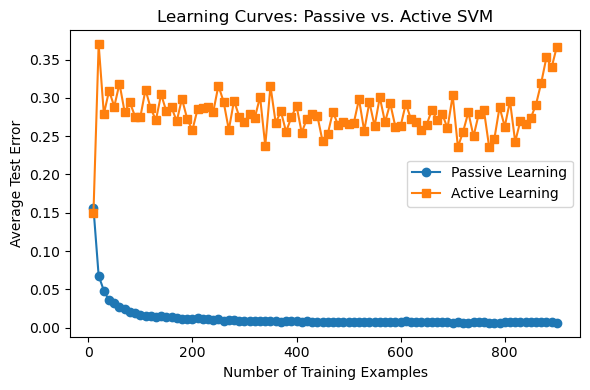

In [15]:
passive_errors = passive_learning_curve(banknotes, runs=50)
active_errors  = active_learning_curve(banknotes, runs=50)

# Training set sizes: 10, 20, ..., 900
sizes = 10 * np.arange(1, len(passive_errors) + 1)

plt.figure(figsize=(6, 4))
plt.plot(sizes, passive_errors, marker='o', label='Passive Learning')
plt.plot(sizes, active_errors,  marker='s', label='Active Learning')
plt.title("Learning Curves: Passive vs. Active SVM")
plt.xlabel("Number of Training Examples")
plt.ylabel("Average Test Error")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
data_path = Path("../data/data_banknote_authentication.txt")
cols = ['variance','skewness','curtosis','entropy','class_label']
banknotes = pd.read_csv(data_path, header=None, names=cols)

# Normalize helper
def normalize(X_tr, X_te):
    scaler = Normalizer().fit(X_tr)
    return scaler.transform(X_tr), scaler.transform(X_te)

# Passive learning
def passive_learning_curve(data, runs=50):
    n_test = 472
    train_acc, test_acc = [], []
    for seed in range(1, runs+1):
        # split & normalize
        tr, te = train_test_split(data, test_size=n_test,
                                  stratify=data['class_label'],
                                  random_state=seed)
        X_tr, y_tr = tr.iloc[:,:-1].values, tr['class_label'].values
        X_te, y_te = te.iloc[:,:-1].values, te['class_label'].values
        X_trn, X_ten = normalize(X_tr, X_te)
        # pick C once
        cv = StratifiedKFold(5, shuffle=True, random_state=seed)
        rnd = RandomizedSearchCV(LinearSVC(penalty='l1', dual=False, max_iter=10000),
                                 {'C': loguniform(1e-3,1e3)},
                                 n_iter=10, cv=cv, scoring='f1_weighted',
                                 n_jobs=-1, random_state=seed)
        rnd.fit(X_trn, y_tr); C = rnd.best_params_['C']
        # incremental batches
        perm = np.random.RandomState(seed).permutation(len(X_trn))
        model = None
        for i in range(0, len(perm), 10):
            idx = perm[:i+10]
            model = LinearSVC(penalty='l1', dual=False, C=C, max_iter=10000)
            model.fit(X_trn[idx], y_tr[idx])
        ta, te_accu = accuracy_score(y_tr, model.predict(X_trn)), accuracy_score(y_te, model.predict(X_ten))
        train_acc.append(ta); test_acc.append(te_accu)
        print(f"{seed}\t{ta:.4f}\t{te_accu:.4f}")
    return np.array(train_acc), np.array(test_acc)

# Active learning
def active_learning_curve(data, runs=50):
    n_test = 472
    train_acc, test_acc = [], []
    for seed in range(1, runs+1):
        tr, te = train_test_split(data, test_size=n_test,
                                  stratify=data['class_label'],
                                  random_state=seed)
        X_tr, y_tr = tr.iloc[:,:-1].values, tr['class_label'].values
        X_te, y_te = te.iloc[:,:-1].values, te['class_label'].values
        X_trn, X_ten = normalize(X_tr, X_te)
        cv = StratifiedKFold(5, shuffle=True, random_state=seed)
        rnd = RandomizedSearchCV(LinearSVC(penalty='l1', dual=False, max_iter=10000),
                                 {'C': loguniform(1e-3,1e3)},
                                 n_iter=10, cv=cv, scoring='f1_weighted',
                                 n_jobs=-1, random_state=seed)
        rnd.fit(X_trn, y_tr); C = rnd.best_params_['C']
        rng = np.random.RandomState(seed)
        unlabeled = list(range(len(X_trn)))
        pool = rng.choice(unlabeled, 10, replace=False).tolist()
        unlabeled = [i for i in unlabeled if i not in pool]
        model = None
        while pool:
            model = LinearSVC(penalty='l1', dual=False, C=C, max_iter=10000)
            model.fit(X_trn[pool], y_tr[pool])
            if not unlabeled: break
            dist = np.abs(model.decision_function(X_trn[unlabeled]))
            picks = np.argsort(dist)[:10]
            candidate = [unlabeled[i] for i in picks]
            if len({y_tr[i] for i in candidate})<2:
                candidate = rng.choice(unlabeled, 10, replace=False).tolist()
            pool += candidate
            unlabeled = [i for i in unlabeled if i not in candidate]
        ta, te_accu = accuracy_score(y_tr, model.predict(X_trn)), accuracy_score(y_te, model.predict(X_ten))
        train_acc.append(ta); test_acc.append(te_accu)
        print(f"{seed}\t{ta:.4f}\t{te_accu:.4f}")
    return np.array(train_acc), np.array(test_acc)

# Run
print("Pass\tTrain\tTest")
passive_learning_curve(banknotes, runs=50)
print("\nActive\tTrain\tTest")
active_learning_curve(banknotes, runs=50)

Pass	Train	Test
1	0.9989	0.9936
2	0.9967	0.9936
3	0.9956	0.9958
4	0.9944	0.9936
5	0.9989	0.9958
6	1.0000	0.9915
7	0.9978	0.9873
8	0.9911	0.9936
9	0.9900	0.9958
10	0.9944	0.9979
11	0.9933	0.9936
12	1.0000	0.9936
13	0.9944	0.9958
14	0.9944	0.9979
15	0.9956	0.9958
16	0.9944	0.9915
17	0.9956	0.9936
18	0.9956	0.9852
19	0.9967	0.9915
20	0.9944	0.9979
21	0.9933	0.9936
22	0.9933	0.9936
23	1.0000	0.9915
24	0.9922	0.9958
25	0.9956	0.9936
26	0.9967	0.9958
27	0.9978	0.9936
28	0.9967	0.9894
29	0.9922	0.9894
30	1.0000	0.9915
31	0.9944	0.9936
32	0.9922	1.0000
33	0.9956	0.9873
34	0.9967	0.9936
35	0.9944	0.9979
36	0.9956	0.9958
37	0.9933	0.9958
38	0.9978	0.9915
39	0.9922	0.9873
40	0.9944	0.9873
41	0.9889	0.9852
42	0.9922	0.9873
43	0.9989	0.9936
44	0.9944	0.9873
45	0.9967	0.9936
46	0.9944	0.9979
47	0.9878	0.9873
48	0.9967	0.9936
49	1.0000	0.9915
50	0.9933	0.9873

Active	Train	Test
1	0.9989	0.9936
2	0.9967	0.9936
3	0.9956	0.9958
4	0.9944	0.9936
5	0.9989	0.9958
6	1.0000	0.9915
7	0.9978	0.9873
8	0.9911	0.9

(array([0.99888889, 0.99666667, 0.99555556, 0.99444444, 0.99888889,
        1.        , 0.99777778, 0.99111111, 0.99      , 0.99444444,
        0.99333333, 1.        , 0.99444444, 0.99444444, 0.99555556,
        0.99444444, 0.99555556, 0.99555556, 0.99666667, 0.99444444,
        0.99333333, 0.99333333, 1.        , 0.99222222, 0.99555556,
        0.99666667, 0.99777778, 0.99666667, 0.99222222, 1.        ,
        0.99333333, 0.99222222, 0.99555556, 0.99666667, 0.99444444,
        0.99555556, 0.99333333, 0.99777778, 0.99222222, 0.99444444,
        0.98888889, 0.99444444, 0.99888889, 0.99444444, 0.99666667,
        0.99444444, 0.98777778, 0.99666667, 1.        , 0.99333333]),
 array([0.99364407, 0.99364407, 0.99576271, 0.99364407, 0.99576271,
        0.99152542, 0.98728814, 0.99364407, 0.99576271, 0.99788136,
        0.99364407, 0.99364407, 0.99576271, 0.99788136, 0.99576271,
        0.99152542, 0.99364407, 0.98516949, 0.99152542, 0.99788136,
        0.99364407, 0.99364407, 0.99152542, 0.

References: <br>
https://archive.ics.uci.edu/ml/datasets/banknote+authentication <br>
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Normalizer.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html<br>
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html<br>
https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.softmax.html<br>

